In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("data/cars.csv")

### Listing counts by make

This table counts how many cleaned listings are available for each make and sorts them from most common to least common. It helps identify which makes have enough data for separate visual analysis.


In [3]:
df.groupby("make").size().reset_index(name="count").sort_values("count", ascending=False)

,make,count
12,ford,54967
7,chevrolet,40955
45,toyota,27106
15,honda,16960
32,nissan,14793
21,jeep,14618
37,ram,13695
14,gmc,13338
4,bmw,12474
9,dodge,9803


### Listing counts by make and model

This table counts cleaned listings for each `(make, model)` pair and sorts the results by make, then by descending count. It helps identify the most common models within each make and supports choosing focused model subsets for later plots.


In [4]:
df.groupby(["make", "model"]).size().reset_index(name="count").sort_values(
    ["make", "count"],
    ascending=[True, False],
)

,make,model,count
1,acura,mdx,1974
3,acura,rdx,1021
6,acura,tl,617
0,acura,ilx,488
7,acura,tlx,403
...,...,...,...
518,volvo,s90,145
517,volvo,s80,143
515,volvo,s40,117
519,volvo,v70,83


### Price distribution

This histogram shows the distribution of vehicle prices across the full cleaned dataset. It helps reveal skew, outliers, and the typical price range before applying transformations.


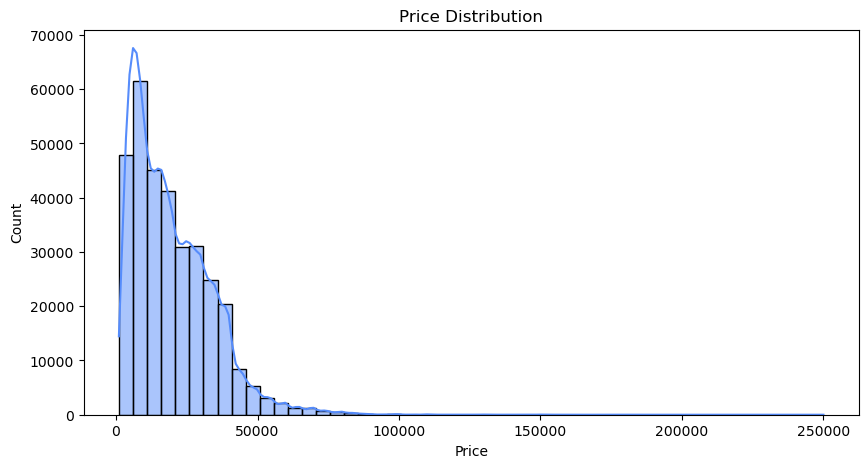

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="price", bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


### Log price distribution

This histogram shows the distribution of `log1p(price)`. The log transform reduces the influence of very high prices and makes the central shape of the price distribution easier to inspect.


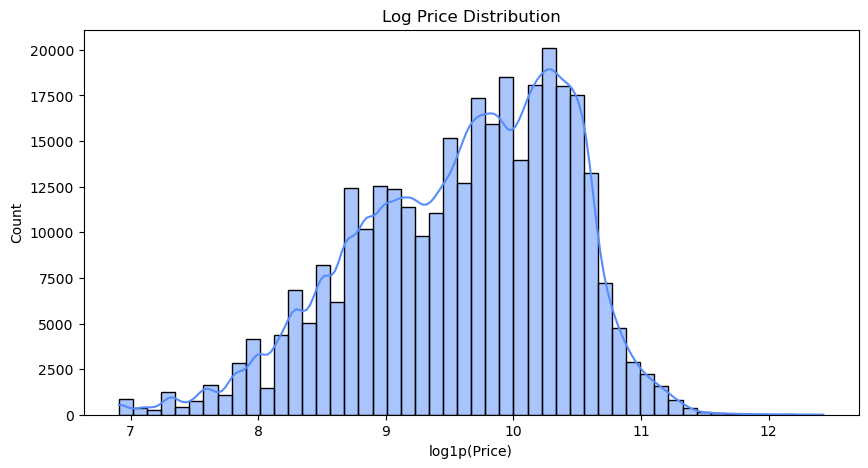

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(x=np.log1p(df["price"]), bins=50, kde=True)
plt.title("Log Price Distribution")
plt.xlabel("log1p(Price)")
plt.ylabel("Count")
plt.show()


### Price, age, and odometer correlation

This heatmap shows pairwise linear correlations between raw `price`, `age`, and `odometer`. It is useful for checking how strongly mileage and age move with price before modeling.


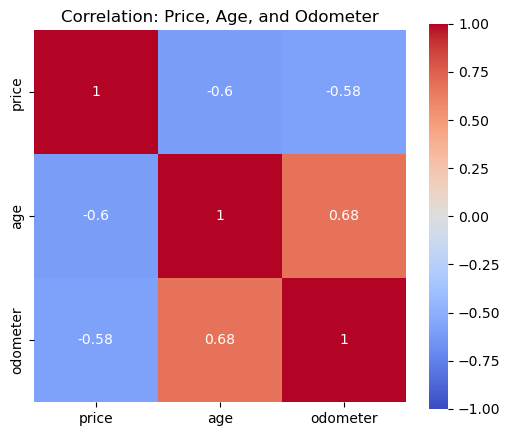

In [7]:
corr = df[["price", "age", "odometer"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlation: Price, Age, and Odometer")
plt.show()


### Log price, age, and odometer correlation

This heatmap shows pairwise linear correlations after replacing raw price with `log1p(price)`. It helps compare whether the log-transformed target has clearer relationships with age and mileage.


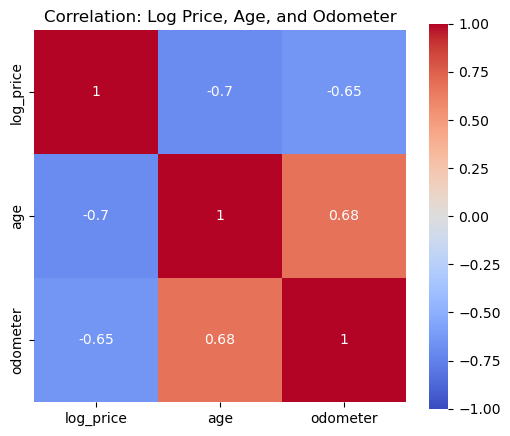

In [8]:
log_corr = df.assign(log_price=np.log1p(df["price"]))[["log_price", "age", "odometer"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(log_corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlation: Log Price, Age, and Odometer")
plt.show()


### Price vs age

This scatterplot shows the relationship between vehicle price and age across the full cleaned dataset. It provides a broad view of depreciation patterns without separating by make or model.


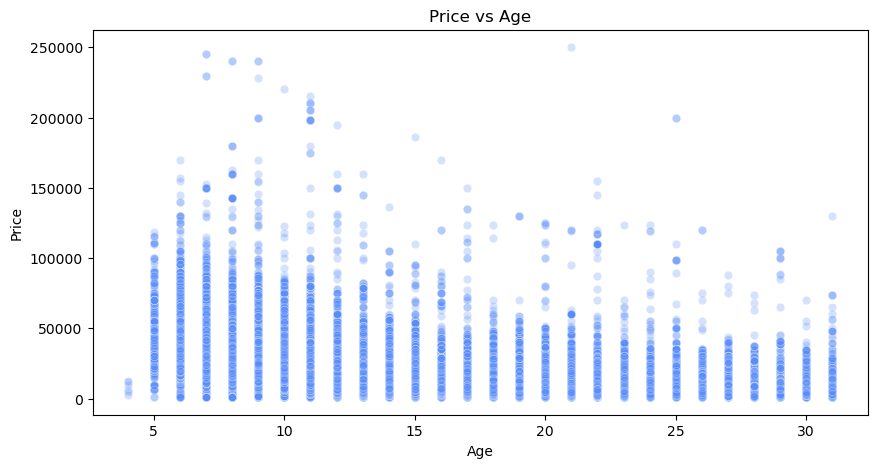

In [9]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="age", y="price", alpha=0.25)
plt.title("Price vs Age")
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()


### Price vs odometer

This scatterplot shows the relationship between vehicle price and odometer reading across the full cleaned dataset. It helps reveal how mileage relates to price before narrowing the analysis by make or model.


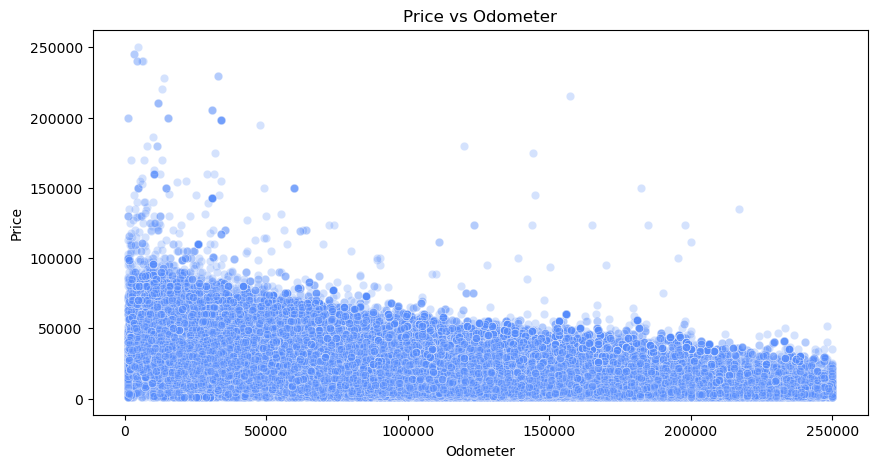

In [10]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="odometer", y="price", alpha=0.25)
plt.title("Price vs Odometer")
plt.xlabel("Odometer")
plt.ylabel("Price")
plt.show()


### Outlier boxplots

These boxplots show the distribution and potential outliers for `price`, `age`, and `odometer` separately. Plotting them on separate axes keeps the different feature scales readable.


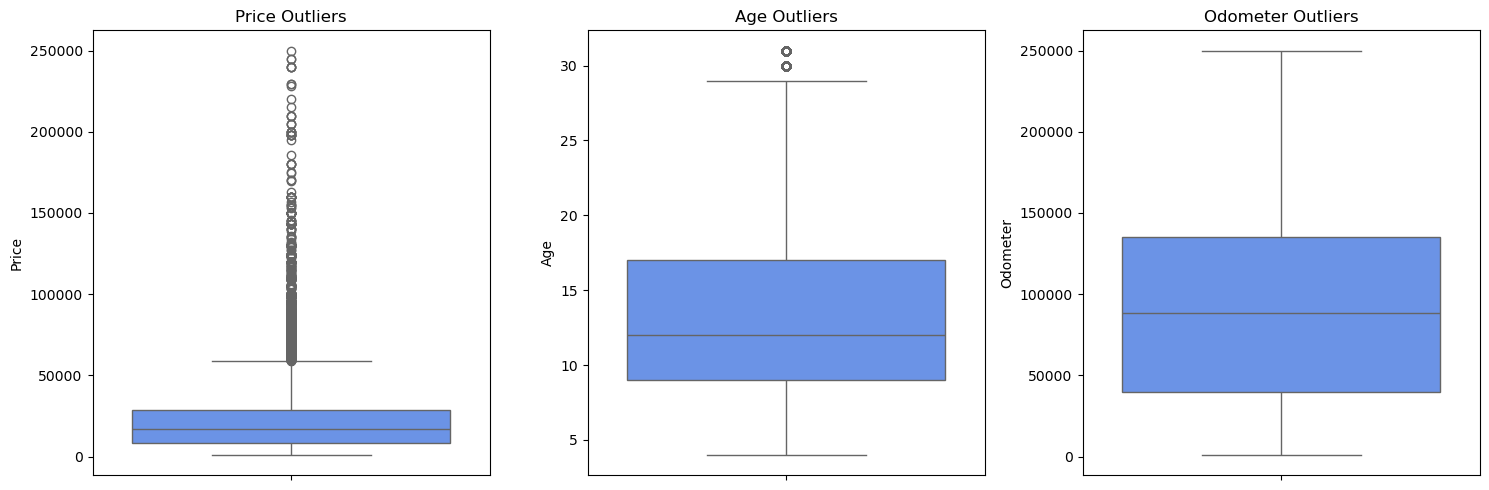

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, y="price", ax=axes[0])
axes[0].set_title("Price Outliers")
axes[0].set_ylabel("Price")

sns.boxplot(data=df, y="age", ax=axes[1])
axes[1].set_title("Age Outliers")
axes[1].set_ylabel("Age")

sns.boxplot(data=df, y="odometer", ax=axes[2])
axes[2].set_title("Odometer Outliers")
axes[2].set_ylabel("Odometer")

plt.tight_layout()
plt.show()


### Price outlier cleanup

The price boxplot suggests the main outlier issue is in the upper tail. This step removes the most expensive 1% of listings by computing the 99th percentile price and keeping only rows at or below that threshold. The resulting `df_clean` dataframe preserves the original `df` while giving us a less extreme target distribution to inspect.


99th percentile price cutoff: $65,590
Rows before cleanup: 326,408
Rows after cleanup: 323,145
Rows removed: 3,263


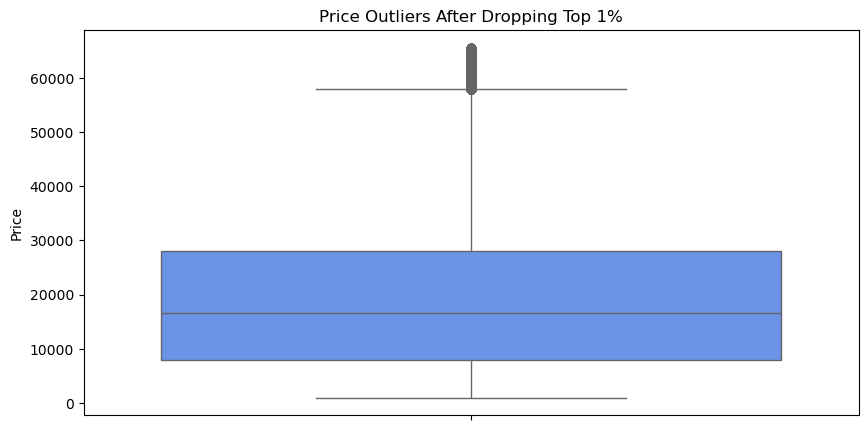

In [12]:
price_upper = df["price"].quantile(0.99)

df_clean = df[df["price"] <= price_upper].copy()

print(f"99th percentile price cutoff: ${price_upper:,.0f}")
print(f"Rows before cleanup: {len(df):,}")
print(f"Rows after cleanup: {len(df_clean):,}")
print(f"Rows removed: {len(df) - len(df_clean):,}")

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, y="price")
plt.title("Price Outliers After Dropping Top 1%")
plt.ylabel("Price")
plt.show()


### Cleaned price vs age

This scatterplot repeats the full-dataset price versus age view after removing the top 1% of prices. Using `df_clean` makes the main depreciation pattern easier to see without the highest-price listings stretching the y-axis.


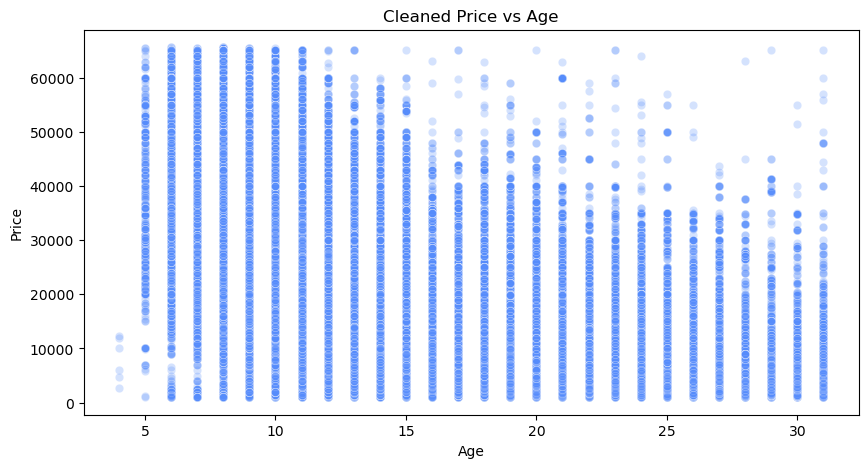

In [13]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x="age", y="price", alpha=0.25)
plt.title("Cleaned Price vs Age")
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()


### Cleaned price vs odometer

This scatterplot repeats the full-dataset price versus odometer view after removing the top 1% of prices. The cleaned view reduces the impact of extreme price values so the relationship between mileage and price is easier to inspect.


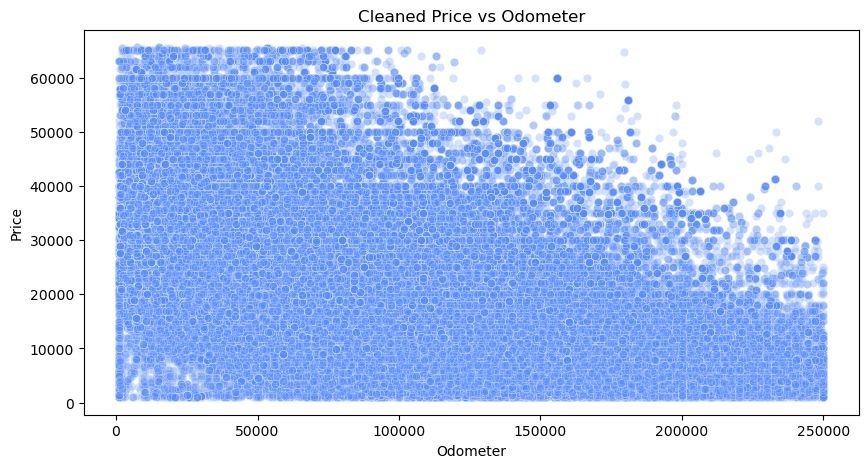

In [14]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x="odometer", y="price", alpha=0.25)
plt.title("Cleaned Price vs Odometer")
plt.xlabel("Odometer")
plt.ylabel("Price")
plt.show()


### Price by condition

This boxplot compares the cleaned price distribution across vehicle condition categories. It shows whether better condition listings tend to have higher prices and whether each category still contains wide price variation.


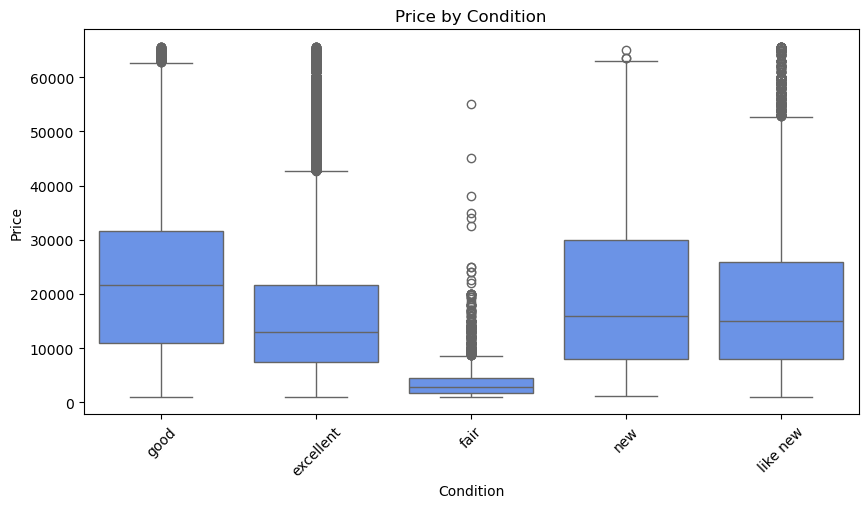

In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="condition", y="price")
plt.title("Price by Condition")
plt.xlabel("Condition")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()


### Median price by condition

This bar chart summarizes each condition category by median cleaned price. It is easier to compare than the full boxplot when the goal is to see the central price tendency for each condition label.


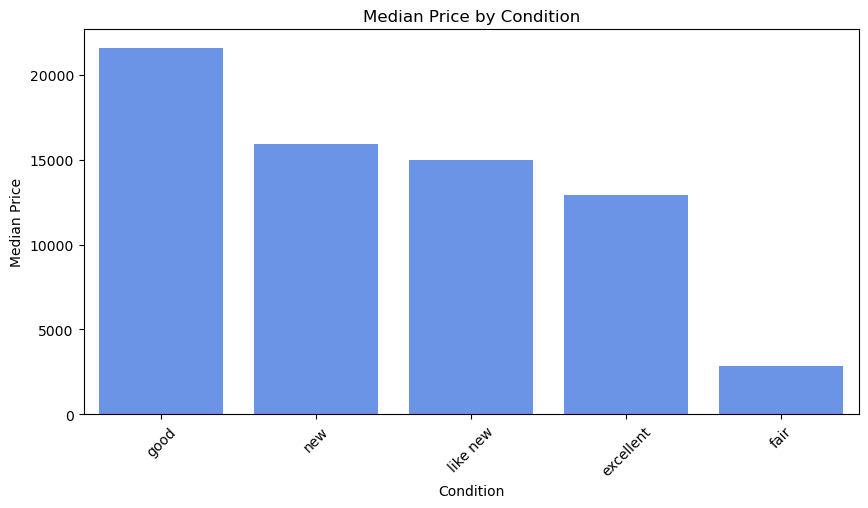

In [16]:
condition_price = (
    df_clean.groupby("condition", as_index=False)["price"]
    .median()
    .sort_values("price", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=condition_price, x="condition", y="price")
plt.title("Median Price by Condition")
plt.xlabel("Condition")
plt.ylabel("Median Price")
plt.xticks(rotation=45)
plt.show()


### Price by top makes

This boxplot compares cleaned price distributions for the 15 most common makes. Limiting the chart to frequent makes keeps it readable while showing how price ranges differ by manufacturer.


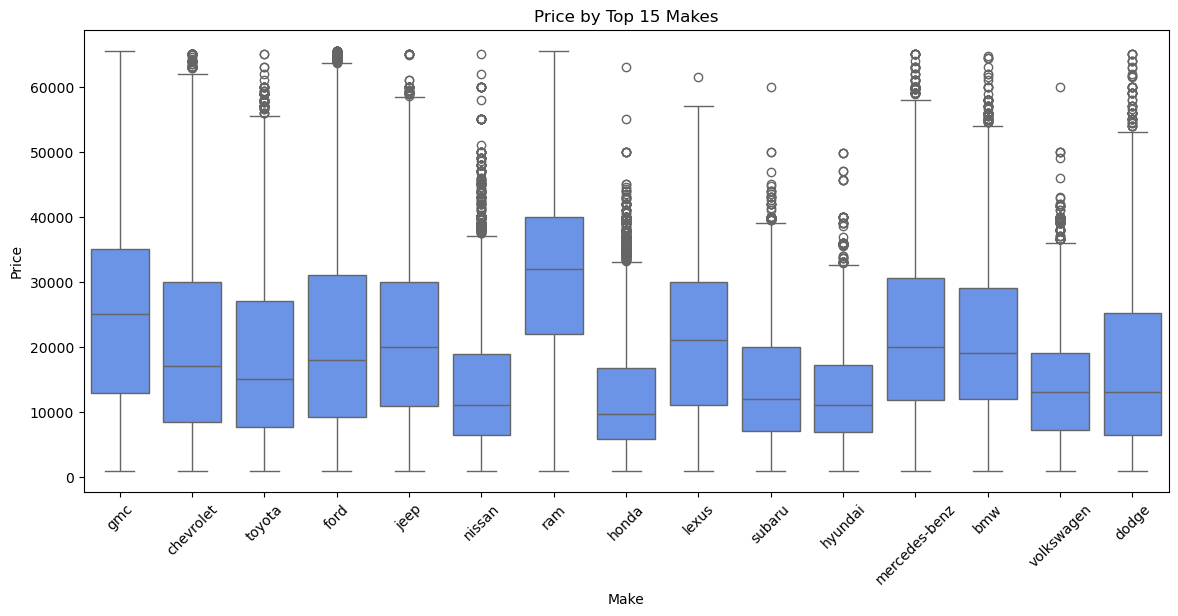

In [17]:
top_makes = df_clean["make"].value_counts().head(15).index
top_make_df = df_clean[df_clean["make"].isin(top_makes)].copy()

plt.figure(figsize=(14, 6))
sns.boxplot(data=top_make_df, x="make", y="price")
plt.title("Price by Top 15 Makes")
plt.xlabel("Make")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()


### Median price by top makes

This bar chart compares median cleaned price across the 15 most common makes. It gives a compact manufacturer-level summary without showing every individual listing.


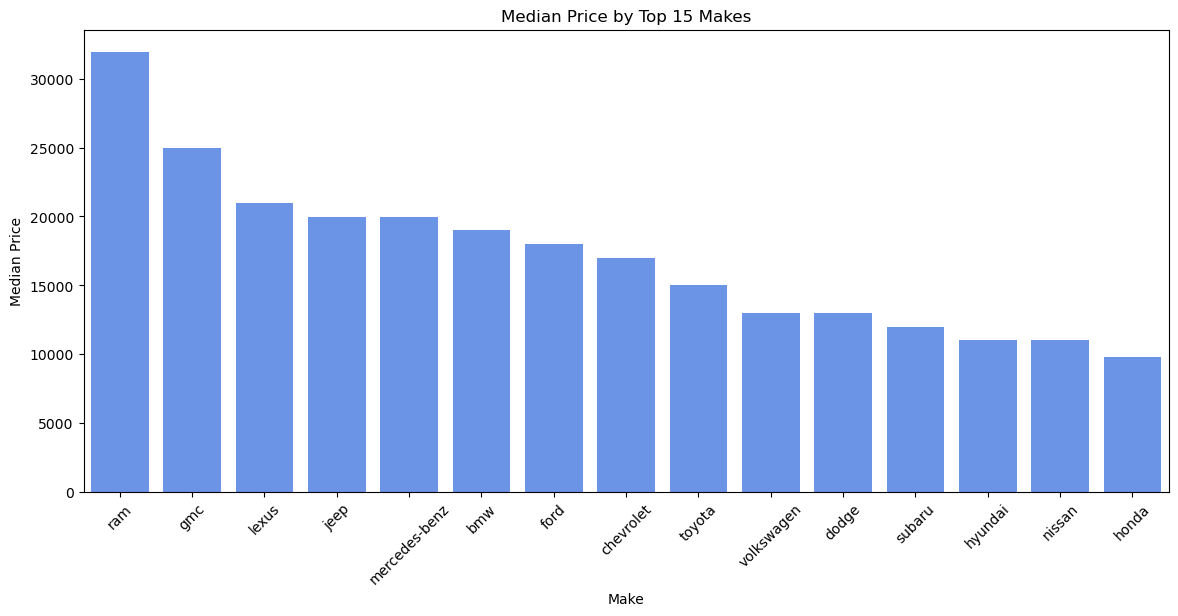

In [18]:
make_price = (
    top_make_df.groupby("make", as_index=False)["price"]
    .median()
    .sort_values("price", ascending=False)
)

plt.figure(figsize=(14, 6))
sns.barplot(data=make_price, x="make", y="price")
plt.title("Median Price by Top 15 Makes")
plt.xlabel("Make")
plt.ylabel("Median Price")
plt.xticks(rotation=45)
plt.show()


### Price by top models

This boxplot compares cleaned price distributions for the 20 most common canonical models. It helps reveal whether model identity has a visible relationship with price while keeping the x-axis manageable.


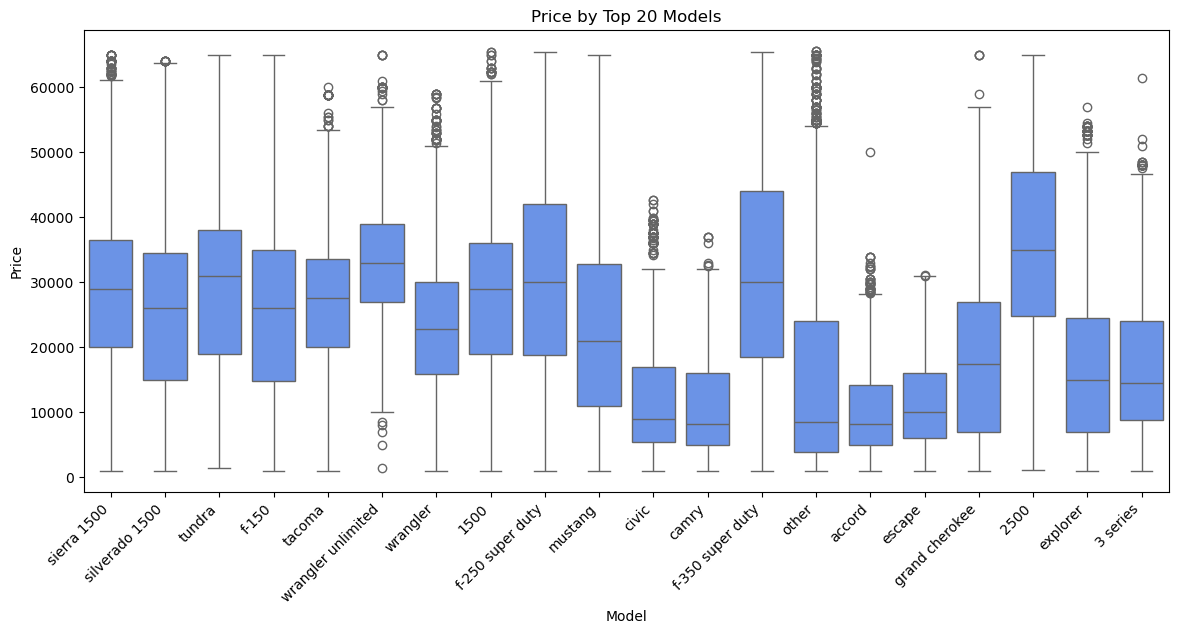

In [19]:
top_models = df_clean["model"].value_counts().head(20).index
top_model_df = df_clean[df_clean["model"].isin(top_models)].copy()

plt.figure(figsize=(14, 6))
sns.boxplot(data=top_model_df, x="model", y="price")
plt.title("Price by Top 20 Models")
plt.xlabel("Model")
plt.ylabel("Price")
plt.xticks(rotation=45, ha="right")
plt.show()
